In [1]:
from ultralytics import YOLO
from matplotlib import pyplot as plt
from ultralytics.engine.results import  Results
import numpy as np
from tqdm import tqdm
import cv2

In [3]:
def image_resize(image, width = None, height = None, inter = cv2.INTER_AREA):
    # initialize the dimensions of the image to be resized and
    # grab the image size
    dim = None
    (h, w) = image.shape[:2]

    # if both the width and height are None, then return the
    # original image
    if width is None and height is None:
        return image

    # check to see if the width is None
    if width is None:
        # calculate the ratio of the height and construct the
        # dimensions
        r = height / float(h)
        dim = (int(w * r), height)

    # otherwise, the height is None
    else:
        # calculate the ratio of the width and construct the
        # dimensions
        r = width / float(w)
        dim = (width, int(h * r))

    # resize the image
    resized = cv2.resize(image, dim, interpolation = inter)

    # return the resized image
    return resized

In [2]:
import easyocr
reader_simplified = easyocr.Reader(['ch_sim'],gpu=True)
reader_traditional = easyocr.Reader(['ch_tra'],gpu=True)
reader_th = easyocr.Reader(['th'],gpu=True)
reader_jp = easyocr.Reader(['ja'],gpu=True)
reader_kr = easyocr.Reader(['ko'],gpu=True)
reader_ru = easyocr.Reader(['ru'],gpu=True)
readerother = easyocr.Reader(['en','id','vi','de','it','tr','es','pt','fr'],gpu=True)

objective_text = ["Opponents Defeated", "Ennemis vaincus", "Musuh Dikalahkan", "Besiegte Gegner", "Avversari sconfitti", 
                  "倒した魔物", "처치한 마물", "Monstros Derrotados", "Побеждено врагов", "击败怪物", "Enemigos derrotados",
                  "กำจัดศัตรูแล้ว", "撃敗怪物", "Yenilen Düşmanlar", "Đánh bại quái"]

In [ ]:
model = YOLO('yolov8n.pt')

model.info()

results = model.train(data='3059imgs dataset\data.yaml', epochs=100, task = 'detect', pretrained=False)


In [ ]:
model = YOLO('yolov8n-cls.pt')
model.info()
results = model.train(data='I:\Genshin utils app/auto-time/auto-time-classify-upsample', epochs=100, task = 'classify', pretrained=False)

In [ ]:
model = YOLO(r'train3059\weights\best.pt')
validation_results = model.val(data='3059imgs dataset\data.yaml', split='test', plots=True)

In [ ]:
#predict from video detect
model = YOLO(r'deploymodel\detect.pt').to(device='cuda:0')
vidpath = r'I:\Genshin utils app\auto-time\downloadedvideos\C6 Arlecchino 5s Chicken ⧸ boss rotation.webm'
a = vidpath[48:-5]
outputpath = fr'I:\Genshin utils app\auto-time\d_annotatedvideos\{a}annotated.mp4'
cap = cv2.VideoCapture(vidpath)
# Get video details
frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(round(cap.get(cv2.CAP_PROP_FPS)))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
objects_present = []
# Define codec and create VideoWriter object to save annotated video
fourcc = cv2.VideoWriter_fourcc(*'H264') # Codec for the output video
out = cv2.VideoWriter(outputpath, fourcc, fps, (frame_width, frame_height))
try:
    while True:
        ret, img = cap.read()
        if ret==False:
            break
        results: Results= model.predict(img)
        for r in results:
            boxes = r.boxes
            objects_present += [[model.names[int(box.cls)] for box in boxes if round(box.conf.item()*100,2)>50]]
            # x,y,w,h = boxes[0].xywh[0]
            # x,y,w,h = int(x.item()-w/2), int(y.item()-h/2), int(w.item()), int(h.item())
            # print(boxes[1])
            # print(model.names[int(boxes[1].cls)])
            # roi = img[y:y+h,x:x+w]
            # cv2.imwrite('ROI.jpg', roi)
            for box in boxes:
                (x,y,x1,y1) = np.array(box.xyxy.cpu(), dtype=int).squeeze()  # get box coordinates in (left, top, right, bottom) format
                class_index = box.cls
                cv2.rectangle(img, (x,y), (x1,y1), (36,255,12), 2)
                cv2.putText(img, 
                            model.names[int(class_index)] + ' ' + str(round(box.conf.item()*100,2)) +'%', 
                            (x,y-10), cv2.FONT_HERSHEY_SIMPLEX,0.9,(36,255,12), 2)

        out.write(img)
            # Custom window
        cv2.namedWindow('custom window', cv2.WINDOW_KEEPRATIO)
        cv2.imshow('custom window', img)
        cv2.resizeWindow('custom window', int(frame_width/2), int(frame_height/2))  
        if cv2.waitKey(1) & 0xFF == ord(' '):
            break
except KeyboardInterrupt:
    print('stop')

cap.release()
out.release()
cv2.destroyAllWindows()   

In [2]:
def checkdirtyframeutil(presentframe):
    nonabyssframes = ['overworld', 'character-screen']
    for i in nonabyssframes:
        if i in presentframe:
            return True
#dirty frame is ignored and don't get scanned by object detect
def check_dirty_frame(res_classify: Results):
    #name: dictionary of classes
    #probs: probabilities of each class
    name, prob = list(res_classify.names.values()), res_classify.probs.data.tolist()
    presentframe  = []
    for i in range(len(prob)):
        if prob[i]>0.1:
            presentframe.append(name[i])
    if len(presentframe)>2: #3 or more classes
        return True
    elif 'abyss' not in presentframe and len(presentframe)>1: #abyss not present and 2 or more classes
        return True
    elif 'abyss' in presentframe and len(presentframe)>1 and checkdirtyframeutil(presentframe):
        #abyss present and at least one of them is outside abyss
        return True
    else: return False

In [39]:
#classify + detect using opencv
detect_model = YOLO(r'runs\detect\detection-v3\weights\best.pt').to(device='cuda:0')
classify_model = YOLO(r'runs\classify\classifyv4-no-multiclass\weights\best.pt').to(device='cuda:0')
vidpath = r'I:\Genshin utils app\auto-time\downloadedvideos\[Genshin 3.7 Abyss Speedrun] Nilou 12 floor in 53s.webm'
a = vidpath[48:]
#do not touch
outputpath = fr'I:\Genshin utils app\auto-time\d_annotatedvideos\{a}cv2_annotated.mp4'
cap = cv2.VideoCapture(vidpath)
# Get video details
frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(round(cap.get(cv2.CAP_PROP_FPS)))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
objects_present = []
# Define codec and create VideoWriter object to save annotated video
fourcc = cv2.VideoWriter_fourcc(*'H264') # Codec for the output video
out = cv2.VideoWriter(outputpath, fourcc, fps, (frame_width, frame_height))
try:
    count = 1
    for i in tqdm(range(total_frames), desc='Processing video', total=total_frames):
        ret, img = cap.read()
        if ret==False:
            break
        # img = image_resize(img, width=640)
        resultclassify: Results= classify_model.predict(source = img, verbose=False)
        resultclassify = resultclassify[0]
        height, width, _ = img.shape
        offset=height
        if check_dirty_frame(resultclassify) == False:
            #add result of classify to objects_present
            objects_present += [list(resultclassify.names[index] for index,i in  enumerate(resultclassify.probs.data.tolist()) if i>0.1)]
            for name, prob in zip(resultclassify.names.values(),resultclassify.probs.data.tolist()):
                if(prob>0.1): #prob of any class
                    offset -= int(height/12)
                    cv2.putText(img, name + ' ' + str("{:.2f}".format(prob*100)) +'%', 
                                    (int(width/12),offset), cv2.FONT_HERSHEY_SIMPLEX,2,(6,6,254), 5)
                if name == 'abyss' and prob>0.1: #prob of abyss
                    resultdetect: Results= detect_model.predict(source = img, verbose=False)
                    resultdetect = resultdetect[0]
                    boxes = resultdetect.boxes
                    #add result of detection to objects_present 
                    objects_present[-1] += [detect_model.names[int(box.cls)] for box in boxes if round(box.conf.item()*100,2)>65]
                    for box in boxes:
                        (x,y,x1,y1) = np.array(box.xyxy.cpu(), dtype=int).squeeze()  # get box coordinates in (left, top, right, bottom) format
                        class_index = box.cls
                        cv2.rectangle(img, (x,y), (x1,y1), (36,255,12), 2)
                        cv2.putText(img, 
                                    detect_model.names[int(class_index)] + ' ' + str(round(box.conf.item()*100,2)) +'%', 
                                    (x,y-10), cv2.FONT_HERSHEY_SIMPLEX,0.9,(36,255,12), 2)
        else:
            objects_present+=[["Dirty Frame"]]
            for name, prob in zip(resultclassify.names.values(),resultclassify.probs.data.tolist()):
                if(prob>0.1): #prob of any class
                    offset -= int(height/12)
                    cv2.putText(img, name + ' ' + str("{:.2f}".format(prob*100)) +'%', 
                                    (int(width/12),offset), cv2.FONT_HERSHEY_SIMPLEX,2,(6,6,254), 5)
            offset -= int(height/12)
            cv2.putText(img, 'Dirty Frame', (int(width/12),offset), cv2.FONT_HERSHEY_SIMPLEX,2,(6,6,254), 5)
        out.write(img)
            # Custom window
        cv2.namedWindow('custom window', cv2.WINDOW_KEEPRATIO)
        cv2.imshow('custom window', img)
        cv2.resizeWindow('custom window', int(frame_width/2), int(frame_height/2))  
        if cv2.waitKey(1) & 0xFF == ord(' '):
            break
except KeyboardInterrupt:
    print('stop')

cap.release()
out.release()
cv2.destroyAllWindows()   

Processing video: 100%|██████████| 684/684 [04:37<00:00,  2.47it/s]


In [44]:
#Combine classify and object detect using imageio
#Time video
detect_model = YOLO(r'runs\detect\detection-v3\weights\best.pt').to(device='cuda:0')
classify_model = YOLO(r'runs\classify\classifyv4-no-multiclass\weights\best.pt').to(device='cuda:0')
vidpath = r'I:\Genshin utils app\auto-time\downloadedvideos\Neuv + Arle ｜ Floor 12 No Reset Speedrun 64s Bookless [4.5 Abyss].webm'
a = vidpath[48:]
#do not touch
outputpath = fr'I:\Genshin utils app\auto-time\d_annotatedvideos\{a}annotated.mp4'
# Get video details
cap = cv2.VideoCapture(vidpath)
frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
objects_present = []
# Define codec and create VideoWriter object to save annotated video
# fourcc = cv2.VideoWriter_fourcc(*'H264') # Codec for the output video
# out = cv2.VideoWriter(outputpath, fourcc, fps, (frame_width, frame_height))
with iio.imopen(outputpath, 'w', plugin='pyav', extension='.mp4') as writer:
    writer.init_video_stream(codec = 'vp9',fps=fps)
    try:
        for i, img in tqdm(enumerate(iio.imiter(vidpath, plugin="pyav")), total=total_frames):
            # print(f"{i}/{total_frames}")
            resultclassify: Results= classify_model.predict(source = img, verbose=False)
            resultclassify = resultclassify[0]
            height, width = frame_height, frame_width
            offset=frame_height
            if check_dirty_frame(resultclassify) == False:
                objects_present += [list(resultclassify.names[index] for index,i in  enumerate(resultclassify.probs.data.tolist()) if i>0.1)]
                for name, prob in zip(resultclassify.names.values(),resultclassify.probs.data.tolist()):
                    if(prob>0.1): #prob of any class
                        offset -= int(height/12)
                        cv2.putText(img, name + ' ' + str("{:.2f}".format(prob*100)) +'%', 
                                    (int(width/12),offset), cv2.FONT_HERSHEY_SIMPLEX,2,(255, 0, 0), 5)
                    if name == 'abyss' and prob>0.1: #prob of abyss
                        resultdetect: Results= detect_model.predict(source = img, verbose=False)
                        resultdetect = resultdetect[0]
                        boxes = resultdetect.boxes
                        objects_present[-1] += [detect_model.names[int(box.cls)] for box in boxes if round(box.conf.item()*100,2)>65]
                        for box in boxes:
                            (x,y,x1,y1) = np.array(box.xyxy.cpu(), dtype=int).squeeze()  # get box coordinates in (left, top, right, bottom) format
                            class_index = box.cls
                            cv2.rectangle(img, (x,y), (x1,y1), (0, 255, 0), 2)
                            cv2.putText(img, 
                                        detect_model.names[int(class_index)] + ' ' + str(round(box.conf.item()*100,2)) +'%', 
                                        (x,y-10), cv2.FONT_HERSHEY_SIMPLEX,0.9,(0, 255, 0), 2)
            else:
                objects_present+=[["Dirty Frame"]]
                for name, prob in zip(resultclassify.names.values(),resultclassify.probs.data.tolist()):
                    if(prob>0.1): #prob of any class
                        offset -= int(height/12)
                        cv2.putText(img, name + ' ' + str("{:.2f}".format(prob*100)) +'%', 
                                    (int(width/12),offset), cv2.FONT_HERSHEY_SIMPLEX,2,(255, 0, 0), 5)
                offset -= int(height/12)
                cv2.putText(img, 'Dirty Frame', (int(width/12),offset), cv2.FONT_HERSHEY_SIMPLEX,2,(255, 0, 0), 5)

            writer.write_frame(img)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            cv2.namedWindow('custom window', cv2.WINDOW_KEEPRATIO)
            cv2.imshow('custom window', img)
            cv2.resizeWindow('custom window', int(frame_width/2), int(frame_height/2))  
            if cv2.waitKey(1) & 0xFF == ord(' '):
                break
    except KeyboardInterrupt:
        print('stop')
    writer.close()
cap.release()
out.release()
cv2.destroyAllWindows()  

  1%|▏         | 119/8574 [01:12<1:26:11,  1.63it/s]


stop


(1252, 20.85)
1920 1080

image 1/1 I:\Genshin utils app\auto-time\testimg.jpg: 384x640 1 objective-text, 1 skill-icons, 30.0ms
Speed: 3.0ms preprocess, 30.0ms inference, 2.0ms postprocess per image at shape (1, 3, 384, 640)
ultralytics.engine.results.Boxes object with attributes:

cls: tensor([0.], device='cuda:0')
conf: tensor([0.9224], device='cuda:0')
data: tensor([[ 67.4494, 203.5372, 168.9740, 236.4754,   0.9224,   0.0000]], device='cuda:0')
id: None
is_track: False
orig_shape: (906, 1610)
shape: torch.Size([1, 6])
xywh: tensor([[118.2117, 220.0063, 101.5245,  32.9382]], device='cuda:0')
xywhn: tensor([[0.0734, 0.2428, 0.0631, 0.0364]], device='cuda:0')
xyxy: tensor([[ 67.4494, 203.5372, 168.9740, 236.4754]], device='cuda:0')
xyxyn: tensor([[0.0419, 0.2247, 0.1050, 0.2610]], device='cuda:0')
objective-text


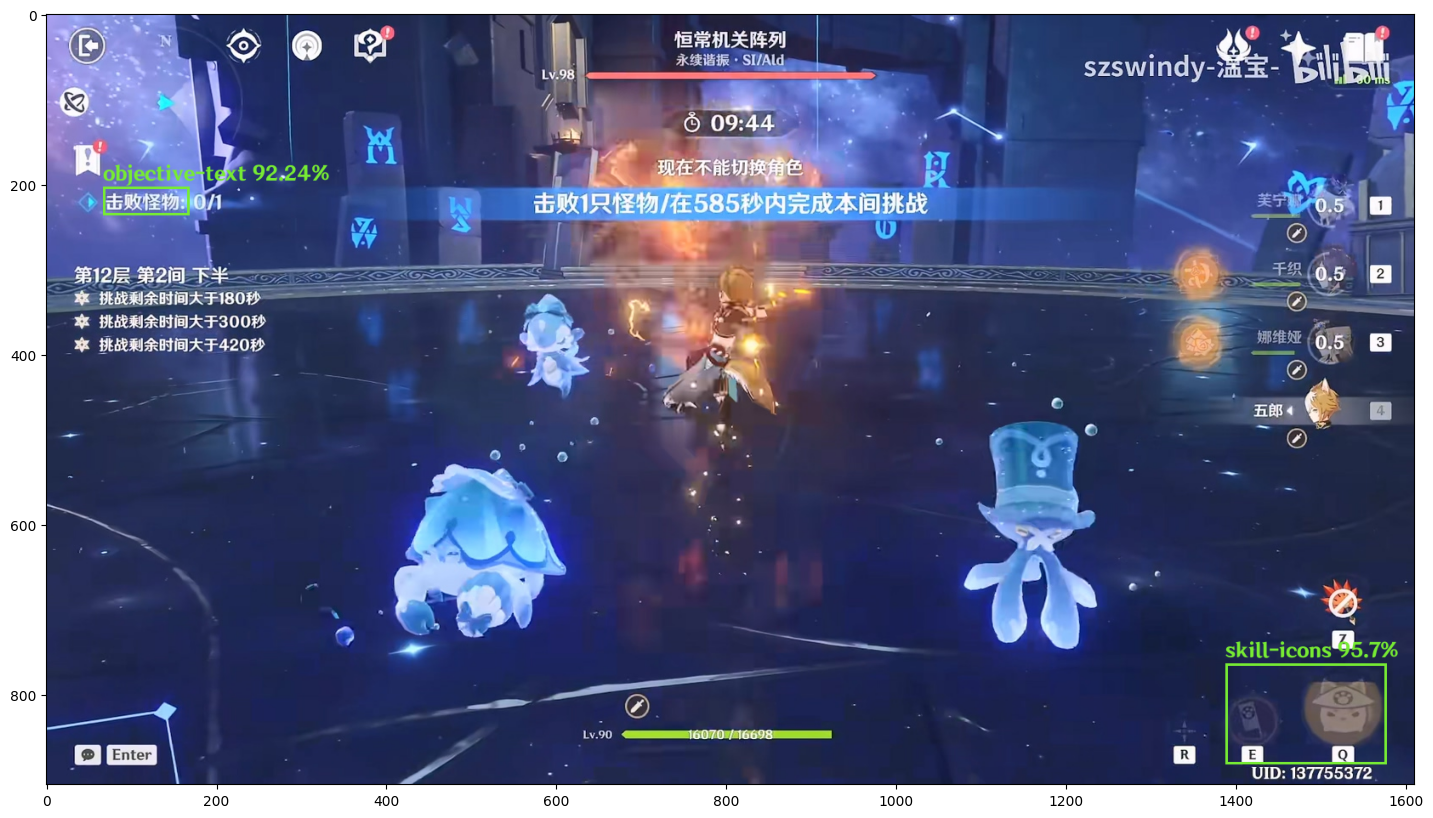

In [26]:
#predicting from image
import imageio.plugins.ffmpeg as ffmp

model = YOLO(r'I:\Genshin utils app\auto-time\deploymodel\detect.pt')
path = r'I:\Genshin utils app\auto-time\testimg.jpg'
img_io = iio.imread(path)
img = Image.fromarray(img_io)
vidpath = r'I:\Genshin utils app\auto-time\downloadedvideos\C3R1 Raiden ｜ 3.3 Spiral Abyss 12-3-1 Jadeplume Terrorshroom 10s.mp4'
metadata = ffmp.imageio_ffmpeg.count_frames_and_secs(vidpath)
print(metadata)
print(iio.improps(vidpath).shape[2], iio.improps(vidpath).shape[1])
results: Results= model.predict(path)
roi = ''
draw = ImageDraw.Draw(img)
font = ImageFont.truetype(r'I:\Genshin utils app\auto-time\zh-cn.ttf', size=23)
for r in results:
    
    boxes = r.boxes
    # x,y,w,h = boxes[1].xywh[0]
    # x,y,w,h = int(x.item()-w/2), int(y.item()-h/2), int(w.item()), int(h.item())
    print(boxes[1])
    print(model.names[int(boxes[1].cls)])
    # roi = img[y:y+h,x:x+w]
    # cv2.imwrite('ROI.jpg', roi)
    for box in boxes:
        
        (x,y,x1,y1) = np.array(box.xyxy.cpu(), dtype=int).squeeze()  # get box coordinates in (left, top, right, bottom) format
        class_index = box.cls
        
        draw.rectangle(((x,y), (x1,y1)), outline=(119, 235, 52), width=3)
        
        draw.text((x,y-30), 
                    model.names[int(class_index)] + ' ' + str(round(box.conf.item()*100,2)) +'%', 
                    fill=(119, 235, 52), stroke_fill=(119, 235, 52),font=font)

plt.figure(figsize=(18,10))
plt.imshow(img)
plt.show()
# (topleft, topright, bottomright, bottomleft) = coord
# tx,ty = (int(topleft[0]), int(topleft[1]))
# bx,by = (int(bottomright[0]), int(bottomright[1]))
# [[148, 246], [519, 246], [519, 290], [148, 290]]
# [148, 246, 519, 290]

In [ ]:
#predicting from image
model = YOLO(r'runs\classify\classify-v1\weights\best.pt').to(device='cuda:0')
path = r'extractedss\Abyss_4.4__Ayaka_top_half_continuous_speedrun_38_39s.webmannotated.mp4_20240322_042631.480.jpg'
img = cv2.imread(path)
height, width, _ = img.shape
results: Results= model.predict(path)
roi = ''
offset = 0
count = 0
for r in results:
    predicts = r.probs.data.tolist()
    for x in predicts: 
        if x>0.1: count+=1
    for index,i in enumerate(predicts):
        if(i>0.1):
            print(r.names[index],': ',i)
            offset += 90
            cv2.putText(img, r.names[index] + ' ' + str(round(i*100,2)) +'%', 
                    (int(width/10),offset), cv2.FONT_HERSHEY_SIMPLEX,2.5,(36,255,12), 10)

plt.figure(figsize=(18,10))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.show()

[([[199, 0], [307, 0], [307, 91], [199, 91]], 'v K', 0.041752506915024204), ([[1239, 63], [1365, 63], [1365, 107], [1239, 107]], '09:50', 0.8030104604952475), ([[2409, 115], [2435, 115], [2435, 133], [2409, 133]], 'd', 0.3914077772297766), ([[2446, 110], [2516, 110], [2516, 134], [2446, 134]], '96 Ms', 0.5651767562190213), ([[313, 333], [381, 333], [381, 373], [313, 373]], 'Dev', 0.3070500042708033), ([[886, 220], [1736, 220], [1736, 436], [886, 436]], '6568B1', 0.6801773994319892), ([[2203, 331], [2328, 331], [2328, 384], [2203, 384]], 'Kaedehara', 0.564727301735535), ([[49, 469], [363, 469], [363, 509], [49, 509]], 'IfhõÆv \'" - 155 97qd2(e1', 0.0008017541752209246), ([[391, 469], [575, 469], [575, 507], [391, 507]], 'Fuist |4rllif', 0.13210124462150888), ([[2244, 462], [2354, 462], [2354, 494], [2244, 494]], 'Shenhe', 0.998676401643128), ([[2369, 469], [2433, 469], [2433, 505], [2369, 505]], '0.8', 0.9911187887191772), ([[2482, 472], [2510, 472], [2510, 502], [2482, 502]], '2', 0.99

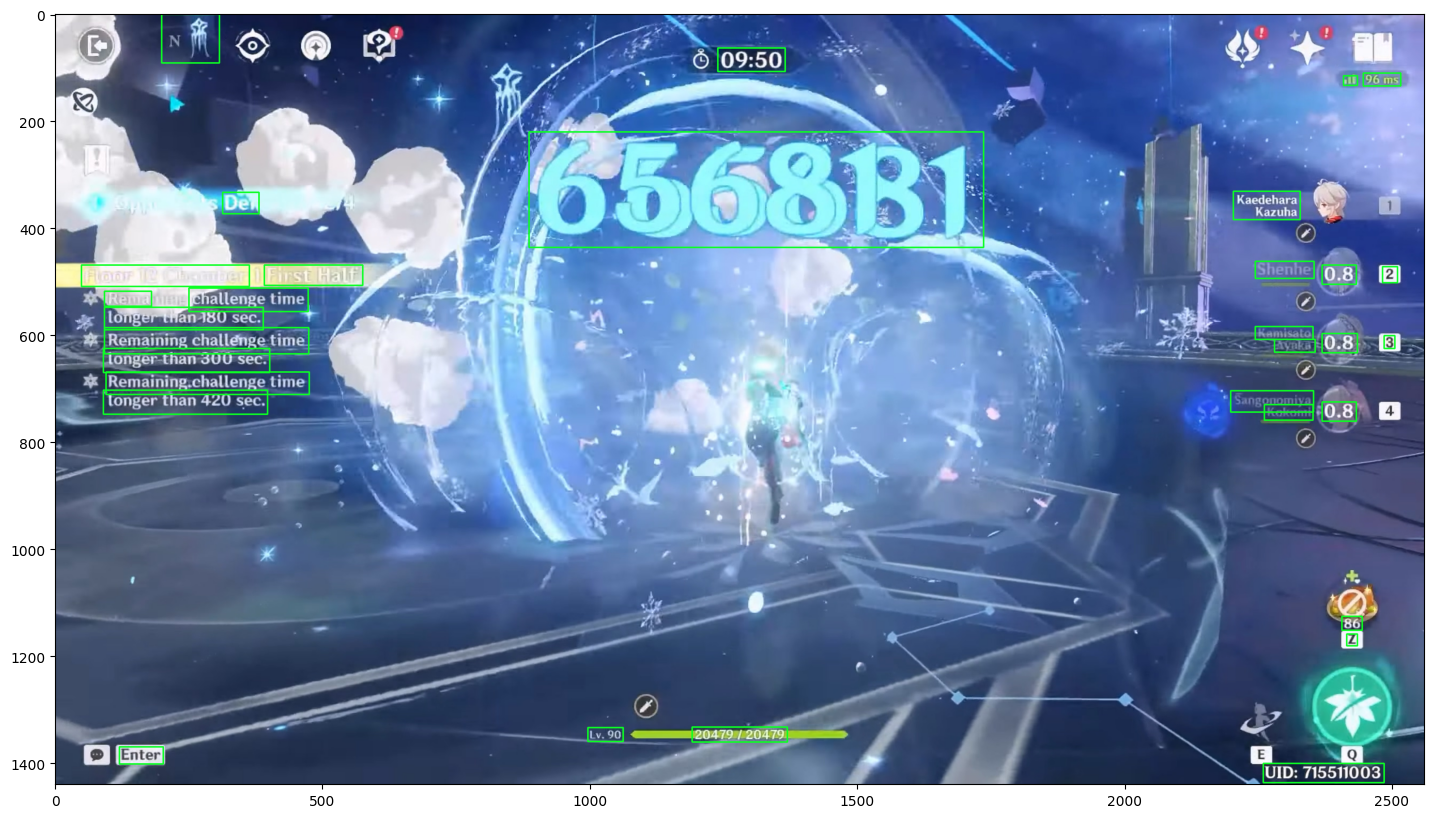

In [4]:
#TEXT SCAN
path = r'extractedss\Abyss_4.4__Ayaka_top_half_continuous_speedrun_38_39s.webm_20240322_081115.741.jpg'
img = cv2.imread(path)
height, width, _ = img.shape
result = readerother.readtext(path)
print(result)
for (coord, text, prob) in result:

  (topleft, topright, bottomright, bottomleft) = coord
  tx,ty = (int(topleft[0]), int(topleft[1]))
  bx,by = (int(bottomright[0]), int(bottomright[1]))
  cv2.rectangle(img, (tx,ty), (bx,by), (36,255,12), 2)
plt.figure(figsize=(18,10))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.show()

In [ ]:
#plot classes distribution over video

model = YOLO(r'train3059\weights\best.pt').to(device='cuda:0')
vidpath = r'I:\Genshin utils app\auto-time\downloadedvideos\C0_Kazuha_and_C0_Keqing_solo_Floor_12_Abyss_2.7.mp4'

cap = cv2.VideoCapture(vidpath)
fps = int(cap.get(cv2.CAP_PROP_FPS))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
objects_present = []
try:
    while True:
        ret, img = cap.read()
        if ret==False:
            break
        results: Results= model.predict(img)
        for r in results:
            boxes = r.boxes
            objects_present += [[model.names[int(box.cls)] for box in boxes if round(box.conf.item()*100,2)>50]]

except KeyboardInterrupt:
    print('stop')



In [ ]:
%matplotlib inline

In [40]:
import pickle
with open(f'framedata/{a}_object present.pkl', 'wb') as f:
    pickle.dump(objects_present, f)

In [6]:
import pickle
with open(r"framedata\y9A5TIkxzyQ.webm.pkl", "rb") as file:
    objects_present = pickle.load(file)
    objects_present = objects_present[3:]

In [3]:
from enum import Enum
from collections import Counter

class Platform(Enum):
    PC = 'skill-icons'
    MOBILE = 'skill-icons-mobile'
    CONTROLLER = 'skill-icons-controller'

class Chamber():
    def __init__(self, start_frame=0, end_frame=0, platform = None, paused=False, fps=60):
        self.start_frame = start_frame
        self.end_frame = end_frame
        self.platform = platform
        self.paused = paused
        self.fps = fps

    def __str__(self):
        return f"Frame info: {self.start_frame}-{self.end_frame} \nPlatform: {self.platform} \nPaused: {self.paused} \nFPS: {self.fps} \nTime: {self.time()}"
    
    def getChamberInfo(self):
        return {'start_frame': self.start_frame, 
                'end_frame': self.end_frame, 
                'platform': self.platform, 
                'paused': self.paused, 
                'fps': self.fps}
    
    def time(self):
        if self.end_frame == 0 or self.start_frame == 0 or self.end_frame<self.start_frame:
            return "Not enough data to calculate time"
        return (self.end_frame - self.start_frame)/self.fps
    
    def getTime(self):
        if self.end_frame == 0: return "End frame must be greater than 0"
        # if self.start_frame == 0: return "Start frame must be greater than 0"
        if self.end_frame<=self.start_frame: return "End frame must be greater than start frame"

        return (self.end_frame - self.start_frame)/self.fps

def flatten(lst):
    return [item for sublist in lst for item in sublist]


In [ ]:
def frame_look_ahead(objectlist ,lookaheadquota):
    #this function look ahead in object list and
    #return None if there's objective-text in the follow up frames (lookaheadquota) is usually 2s
    #the sample is taken from the start of objectlist to lookaheadquota

    #return the objects present in the sample and occurence frequency if there's an end screen in the follow up frames
    pauses = ['BP-screen', 'coop-screen', 'book-screen', 'mission-screen', 'tutorial-screen', 'wish-screen',
              'map-screen', 'Dirty Frame']
    endscreens = ['transition-screen', 'transition-screen-2','character-screen','overworld','abyss', 'Dirty Frame']
    # abyssobjectives = ['abyss','objective-text','skill-icons','skill-icons-controller','skill-icons-mobile']
    if lookaheadquota>len(objectlist):
        lookaheadquota = len(objectlist)
    lst = objectlist[:lookaheadquota]
    lst = flatten(lst)
    counter = Counter(lst,)
    res = counter.most_common()
    object = [i[0] for i in res]
    occurence = [i[1] for i in res]
    print(object, occurence)
    if 'objective-text' in object:
        if occurence[object.index('objective-text')] >= 10:
            return None
    if check_end_screen1(object, occurence) == True:
        return object, occurence
    
    

def getPlatform(objectlist: list):
    for frame in objectlist:
        if 'skill-icons' in frame:     
            return Platform.PC
        if 'skill-icons-controller' in frame:
            return Platform.CONTROLLER
        if 'skill-icons-mobile' in frame:
            return Platform.MOBILE

def check_end_screen1(objects:list, occurence):
    #check for if endscreens are in the passed objects list
    #return True if the number of occurences of a single endcreen is bigger than 10
    endscreens = ['transition-screen', 'transition-screen-2','character-screen', 'overworld']
    for i in endscreens:
        if i in objects:
            if occurence[objects.index(i)] >= 10:
                return True
    return False

def find_element_index(nested_list, element, skipindexes):
    #find the first element in the nestedlist that match "{element}"
    #if there's an objective-text in the frame, it will skip the frame, otherwise it will return the index
    #of the element that match "{element}"
    for outer_index, inner_list in enumerate(nested_list):
        if outer_index < skipindexes:
            continue
        if element in inner_list and 'objective-text' not in inner_list:
            return outer_index

def verify_start_frame(objectlist: list, start_frame: int, skillicon, fps):
    #verify the start frame of the chamber picked by find_element_index()
    transitionframes = ['transition-screen', 'transition-screen-2']
    sample = objectlist[start_frame: start_frame + fps * 2]
    sample = flatten(sample)
    counter = Counter(sample)
    res = counter.most_common()
    object = [i[0] for i in res]
    occurence = [i[1] for i in res]
    if 'objective-text' not in object and set(object).intersection(transitionframes) != set():
        return False
    else: return True


def verify_chamber(objectlist: list, framerate, skippedframes=0):
    #objectlist: list of objects present in video
    #framerate: fps of video
    #skippedframes: number of frames to skip while scanning
    endscreens = ['transition-screen', 'transition-screen-2','character-screen','overworld', 'Dirty Frame']
    abyss_pauses = ['BP-screen', 'coop-screen', 'book-screen', 'mission-screen', 'tutorial-screen', 'wish-screen',
              'map-screen', 'Dirty Frame']
    lookaheadquota = framerate*2
    chamber = Chamber(fps=framerate)
    chamber.platform = getPlatform(objectlist)

    chamber.start_frame = find_element_index(objectlist, chamber.platform.value, skippedframes)
    skipframes = chamber.start_frame
    if skipframes == None:
        raise ValueError('Video ended or verification in previous chamber failed. Please check video.')
    while verify_start_frame(objectlist, skipframes, chamber.platform, framerate) == False:
        chamber.start_frame = find_element_index(objectlist, chamber.platform.value, skipframes)
        skipframes += framerate
        print(skipframes)
    print('Start frame:',chamber.start_frame, 'Skipped to frame:', skippedframes)
    chamber_ending = 0

    for i, frame in enumerate(objectlist):
        # iterate through the object list
        if i < skippedframes: continue #skip previous timed chambers
        if 'objective-text' in frame:
            if set(frame).intersection(endscreens) == set(): continue
            # if objective text is present and not an end screen
        elif 'objective-text' not in frame:
            res = frame_look_ahead(objectlist[i:], lookaheadquota)
            print(i, res,'\n')
            if res is None: continue
            lookaheadobjects, lookaheadoccurences = res
            if not set(lookaheadobjects).issubset(endscreens) and set(lookaheadobjects).intersection(endscreens) == set():
                continue
            if set(lookaheadobjects).issubset(abyss_pauses): chamber.paused = True
            elif check_end_screen1(lookaheadobjects, lookaheadoccurences) == True and 'objective-text' in objectlist[i-1]: 
                chamber.end_frame = i-1
                chamber_ending = i
                print("end frame found")
                break
    return chamber, chamber_ending

def verify_run(objectlist: list, framerate, no_rooms):
    chambers = []
    video_mark=0
    for i in range(no_rooms):
        print('Chamber: ',i,'Starting point:', video_mark)
        chamber, video_mark = verify_chamber(objectlist, framerate, skippedframes=video_mark+1 if video_mark>0 else video_mark)
        chambers += [chamber]
        print(chamber,'\n')
    return chambers

a: list[Chamber]
a = verify_run(objects_present, 30, 1)
totalTime=0
for i in a:
    totalTime += i.getTime()
print(totalTime)

In [82]:
class A:
    def __init__(self, attribute):
        self.attribute = attribute
    
    def __eq__(self, other):
        return isinstance(other, A)

    def __hash__(self):
        return hash("A")

# Example usage
from collections import Counter

# Define instances of class A
a1 = A(10)
a2 = A(20)
a3 = A(10)

# Create a Counter with instances of class A
counter = Counter([a1, a2, a3])

# Print the Counter
print(counter)


Counter({<__main__.A object at 0x0000029A8C5CA620>: 3})


In [8]:
from collections import Counter
def flatten(lst):
    return [item for sublist in lst for item in sublist]
list1 = [['a','b','c'],['d','e','f'],['a','g','h']]
list1 = flatten(list1)
c = Counter(list1)
print(c)
print(set(['a']).intersection(list1))
assert set(['a']).intersection(list1), "not subset"

Counter({'a': 2, 'b': 1, 'c': 1, 'd': 1, 'e': 1, 'f': 1, 'g': 1, 'h': 1})
{'a'}


In [4]:
fps = 60

In [42]:
newobjects = []
for frame in objects_present:
    if len(set(['skill-icons', 'skill-icons-controller', 'skill-icons-mobile', 'objective-text']).intersection(set(frame)))>0:
        newobjects += [frame]
    # if 'abyss' in frame:
    #     newobjects += [frame]
    if 'transition-screen' in frame or 'transition-screen-2' in frame:
        newobjects += [frame]
objects_present = newobjects

In [7]:
def find_start_end(objects, icon):
    for i, x in enumerate(objects):
        if icon in x:
            start = i
            break
    for i, x in enumerate(objects[::-1]):
        if 'objective-text' in x:
            end = i
            break
    end = len(objects) - end -1
    return start, end

def transform_tuples(tuples, start, end):
    new_tuples = [(start, tuples[0][0])]
    new_tuples += [(tuples[i][1], tuples[i+1][0]) for i in range(len(tuples)-1)]
    new_tuples.append((tuples[-1][1], end))
    return new_tuples

def find_gaps(objects: list, start, end):
    
    # Initialize variables
    zero_indices = [start] + [i for i, x in enumerate(objects) if 'objective-text' in x] + [end]
    gaps = [(zero_indices[i-1], zero_indices[i]) for i in range(1, len(zero_indices))]

    # Calculate gap lengths
    gap_lengths = [end - start - 1 for start, end in gaps]

    # Find the indices of the two largest gaps
    largest_gap_indices = sorted(range(len(gap_lengths)), key=lambda i: gap_lengths[i], reverse=True)[:2]
    gaps = [gaps[i] for i in largest_gap_indices]

    return sorted(gaps, key=lambda x: x[0])

def find_platform(objects):
    lst = flatten(objects)
    c = Counter(lst)
    maxcount = 0
    platform = Platform.PC
    for ele, count in c.most_common():
        if ele in ['skill-icons', 'skill-icons-controller', 'skill-icons-mobile']:
            if count > maxcount:
                maxcount = count
                platform = ele
    return platform


def find_skill_icons(objects: list, icon, gaps, start, end):
    skill_icons = [start]
    for (chamberbegin, chamberend) in gaps:
        endchamberindex = 0
        for i in list(range(chamberbegin,chamberend))[::-1]:
            if 'transition-screen' in objects[i] or 'transition-screen-2' in objects[i]:
                endchamberindex = i
                # print(i)
                break
    
        for i in list(range(endchamberindex, chamberend)):
            if icon in objects[i]:
                skill_icons.append(i)
                break
    return skill_icons
            
def verify_run(object_list):
    icon = find_platform(object_list)
    start, end = find_start_end(object_list, icon)
    gaps = find_gaps(object_list, start, end)
    print(gaps)
    starts = find_skill_icons(object_list, icon, gaps, start, end)
    print(starts)
    ends =  [x for (x,y) in gaps] + [end]
    print(ends)
    chambers: list[Chamber] = []
    for x,y in zip(starts,ends):
        chambers += [Chamber(start_frame=x, end_frame=y, platform=icon, fps=fps)]
    totalTime = 0
    for i in chambers:
        print(i.getTime())
        totalTime += i.getTime()
    return totalTime
print(verify_run(objects_present))

[(7670, 7838), (12231, 12400)]
[1204, 7785, 12345]
[7670, 12231, 17164]
107.76666666666667
74.1
80.31666666666666
262.18333333333334


In [6]:
from matplotlib.axes import Axes

# Sample data (replace this with your actual data)
classnames = ['BP', 'coop', 
              'objective-text', 'pen', 
              'quests', 'skill-icons', 'skill-icons-controller', 
              'skill-icons-mobile', 'spiral-abyss', 'tutorial', 'wish']
data = objects_present

# Filter out elements other than "plot me" and store their positions
BPindices = [i for i, val in enumerate(data) if "BP-screen" in val]
COOPindices = [i for i, val in enumerate(data) if "coop-screen" in val]
OBJECTIVE_TEXTindices = [i for i, val in enumerate(data) if "objective-text" in val]
PENindices = [i for i, val in enumerate(data) if "book-screen" in val]
QUESTSindices = [i for i, val in enumerate(data) if "mission-screen" in val]
SKILL_ICONSindices = [i for i, val in enumerate(data) if "skill-icons" in val]
SKILL_ICONS_CONTROLLERindices = [i for i, val in enumerate(data) if "skill-icons-controller" in val]
SKILL_ICONS_MOBILEindices = [i for i, val in enumerate(data) if "skill-icons-mobile" in val]
SPIRAL_ABYSSindices = [i for i, val in enumerate(data) if "spiral-abyss" in val]
TUTORIALindices = [i for i, val in enumerate(data) if "tutorial-screen" in val]
WISHindices = [i for i, val in enumerate(data) if "wish-screen" in val]
DIRTY_FRAMEindices = [i for i, val in enumerate(data) if "Dirty Frame" in val]
TRANSITIONindices = [i for i, val in enumerate(data) if "transition-screen" in val]
TRANSITION2indices = [i for i, val in enumerate(data) if "transition-screen-2" in val]

ax: Axes
fig, ax = plt.subplots(figsize=(30, 6))
fig.patch.set_facecolor('black')  # Set figure background color to black
ax.set_facecolor('black')

threshold = 0
if find_platform(objects_present) == 'skill-icons':
    ax.text(-5, (0.1+0.2)/2, 'SKILL ICONS', horizontalalignment='right', verticalalignment='center', rotation='horizontal',color='white')
    for i, idx in enumerate(SKILL_ICONSindices):
        ax.axvspan(idx, idx+1, color='#00ffce', alpha=0.5,ymin=0.1, ymax=0.2)
elif find_platform(objects_present) == 'skill-icons-controller':
    ax.text(-5, (0.1+0.2)/2, 'SKILL ICONS CONTROLLER', horizontalalignment='right', verticalalignment='center', rotation='horizontal',color='white')
    for i, idx in enumerate(SKILL_ICONS_CONTROLLERindices):
        ax.axvspan(idx, idx+1, color='#00b7eb', alpha=0.5,ymin=0.1, ymax=0.2)
elif find_platform(objects_present) == 'skill-icons-mobile':
    ax.text(-5, (0.1+0.2)/2, 'SKILL ICONS MOBILE', horizontalalignment='right', verticalalignment='center', rotation='horizontal',color='white')
    for i, idx in enumerate(SKILL_ICONS_MOBILEindices):
        ax.axvspan(idx, idx+1, color='#ff8000', alpha=0.5,ymin=0.1, ymax=0.2)

ax.text(-5, (0.2+0.3)/2, 'OBJECTIVE TEXT', horizontalalignment='right', verticalalignment='center', rotation='horizontal',color='white')
for i, idx in enumerate(OBJECTIVE_TEXTindices):
    ax.axvspan(idx, idx+1, color='#ffff00', alpha=0.5,ymin=0.2, ymax=0.3)

for i, idx in enumerate(BPindices):
    ax.axvspan(idx, idx+1, color='#ffabab', alpha=1,ymin=0.3, ymax=0.4)
for i, idx in enumerate(COOPindices):
    ax.axvspan(idx, idx+1, color='#CC6B1C', alpha=1,ymin=0.3, ymax=0.4)
for i, idx in enumerate(PENindices):
    ax.axvspan(idx, idx+1, color='#8622ff', alpha=1,ymin=0.3, ymax=0.4)
for i, idx in enumerate(QUESTSindices):
    ax.axvspan(idx, idx+1, color='#0e7afe', alpha=1,ymin=0.3, ymax=0.4)
for i, idx in enumerate(SPIRAL_ABYSSindices):
    ax.axvspan(idx, idx+1, color='#fe0056', alpha=1,ymin=0.3, ymax=0.4)
for i, idx in enumerate(TUTORIALindices):
    ax.axvspan(idx, idx+1, color='#0000ff', alpha=1,ymin=0.3, ymax=0.4)
for i, idx in enumerate(WISHindices):
    ax.axvspan(idx, idx+1, color='#ff00ff', alpha=1,ymin=0.3, ymax=0.4)

for i, idx in enumerate(TRANSITIONindices):
    ax.axvspan(idx, idx+1, color='#FFFFFF', alpha=1,ymin=0.1, ymax=0.3)
for i, idx in enumerate(TRANSITION2indices):
    ax.axvspan(idx, idx+1, color='#8D8C8C', alpha=1,ymin=0.1, ymax=0.3)
ax.text(-5, (0.4+0.3)/2, 'PAUSES', horizontalalignment='right', verticalalignment='center', rotation='horizontal',color='white')

for i, idx in enumerate(DIRTY_FRAMEindices):
    ax.axvspan(idx, idx+1, color='#287E05', alpha=1,ymin=0.4, ymax=0.5)
ax.text(-5, (0.4+0.5)/2, 'DIRTY FRAME', horizontalalignment='right', verticalalignment='center', rotation='horizontal',color='white')

# Set limits and labels
ax.set_xlim(0, len(data))
ax.set_ylim(0, 1)
ax.set_xlabel('Timeline (frame)', color='white')
ax.set_title('Object Occurrences', color='white')
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')
ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')
ax.spines['bottom'].set_color('white')
ax.spines['top'].set_color('white') 
ax.spines['right'].set_color('white')
ax.spines['left'].set_color('white')
legend_handles = [
    plt.Rectangle((0,0),1,1, color='#ffabab', alpha=1),
    plt.Rectangle((0,0),1,1, color='#CC6B1C', alpha=1),
    plt.Rectangle((0,0),1,1, color='#8622ff', alpha=1),
    plt.Rectangle((0,0),1,1, color='#0e7afe', alpha=1),
    plt.Rectangle((0,0),1,1, color='#fe0056', alpha=1),
    plt.Rectangle((0,0),1,1, color='#0000ff', alpha=1),
    plt.Rectangle((0,0),1,1, color='#ff00ff', alpha=1)
]
legend_labels = ['BP', 'COOP', 'BOOK', 'QUESTS', 'SPIRAL ABYSS', 'TUTORIAL', 'WISH']
ax.legend(legend_handles, legend_labels, title='Pauses screens', loc='upper right')

plt.grid(False)
plt.yticks([])  # Hide y-axis ticks

plt.show()

NameError: name 'plt' is not defined

In [22]:
def find_index_in_reversed_part(lst, start, end, target):
    print(lst, start, end ,target)
    a = list(range(start,end))[::-1]
    reversed_index = 0
    found = False
    for i in a:
        if target == lst[i]:
            reversed_index = i
            found = True
    if found == False: return None
    gapend = end - reversed_index
    gapstart = reversed_index-start
    print(gapstart, gapend)
    res = len(lst[:start]) + gapend
    return res

# Test the function
lst = [1,2,3,4,4,9,10,7,6,5]
res = 0
print(find_index_in_reversed_part(lst, 4, 9, 4))  # Output: 6

[1, 2, 3, 4, 4, 9, 10, 7, 6, 5] 4 9 4
0 5
9
